# From linear individual policy rules to the aggregate law of motion

Suppose the individual policy function is approximately linear in individual assets:
$$
k' = a(K,e,z) + b(K,e,z)\,k.
$$

Let $\mu(k,e\mid K,z)$ denote the cross-sectional distribution of agents over $(k,e)$ conditional on aggregate capital $K$ and aggregate state $z$. Then the aggregate law of motion is
$$
K' = \sum_e \int \bigl[a(K,e,z)+b(K,e,z)k\bigr]\mu(k,e\mid K,z)\,dk.
$$

Therefore,
$$
K'
= \sum_e a(K,e,z)\mu_e(K,z)
+ \sum_e b(K,e,z)K_e(K,z),
$$
where
$$
\mu_e(K,z)=\int \mu(k,e\mid K,z)\,dk
$$
is the mass of agents with employment state $e$, and
$$
K_e(K,z)=\int k\,\mu(k,e\mid K,z)\,dk
$$
is the total capital held by agents in state $e$.
Since total aggregate capital satisfies
$$
K=\sum_e K_e(K,z),
$$
define the wealth share of agents in employment state $e$ by
$$
\omega_e(K,z):=\frac{K_e(K,z)}{K},
\qquad \sum_e \omega_e(K,z)=1.
$$

Then
$$
K_e(K,z)=\omega_e(K,z)\,K,
$$
so the aggregate law of motion can be rewritten as
$$
K'
=
\sum_e a(K,e,z)\mu_e(K,z)
+
\sum_e b(K,e,z)\omega_e(K,z)\,K.
$$

Now define
$$
A(K,z):=\sum_e a(K,e,z)\mu_e(K,z),
\qquad
B(K,z):=\sum_e b(K,e,z)\omega_e(K,z).
$$

Then
$$
\boxed{K' = A(K,z)+B(K,z)K.}
$$

However, we still cannot prove that $A(K,z)$ and $B(K,z)$ are constant in $K$. In fact, they are not constant in general. 

# Compare numerical results of two perceived laws of motion:

In this section, we compare the results of two perceived laws of motion (one with log K and one with linear K) by plotting them together. 

The estimated parameters for both cases are printed. Additionally, we plot the perceived law of motion for both cases on the same graph to visually compare them.

Additionally, we simulate the economy using both sets of parameters and plot the resulting paths of aggregate capital K over time to see how they differ in terms of dynamics.

Additionally, we compute the Den Haan diagnostic for both cases to quantitatively assess the convergence of the perceived law of motion to the true law of motion.

2×2 Matrix{Float64}:
 0.0873823  0.9634
 0.0912525  0.963876

Comparison of solved perceived laws of motion

[Log-law notebook]
law_type = log
coeff = 
R2 by state = [0.9997917569331751, 0.9998994172155053]

[Linear-law notebook]
law_type = linear
coeff = 
R2 by state = [0.9997934264437218, 0.9998985866157637]

Summary table
Law          | a_bad        | b_bad        | a_good       | b_good      
log          | 0.087382     | 0.963400     | 0.091253     | 0.963876    
linear       | 0.427959     | 0.960634     | 0.431172     | 0.965687    

Law          | R2_bad       | R2_good     
log          | 0.999792     | 0.999899    
linear       | 0.999793     | 0.999899    

Comparison of simulated aggregate capital paths
Law          | mean(K)      | std(K)       | min(K)       | max(K)      
log          | 11.708787    | 0.352376     | 10.975888    | 14.949833   
linear       | 11.707554    | 0.350687     | 10.971209    | 14.949833   


2×2 Matrix{Float64}:
 0.427959  0.960634
 0.431172  0.965687

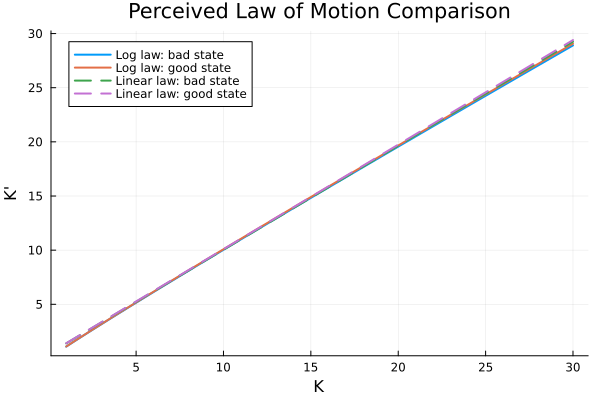

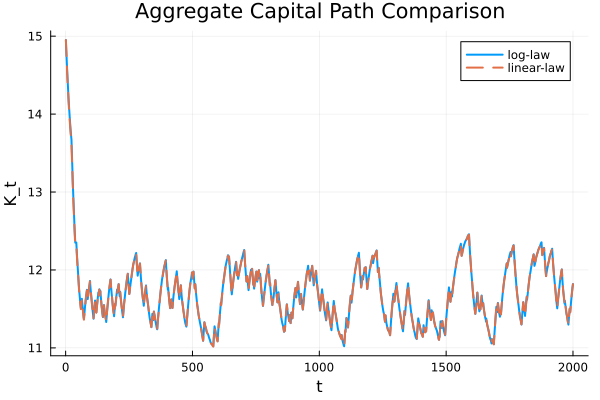

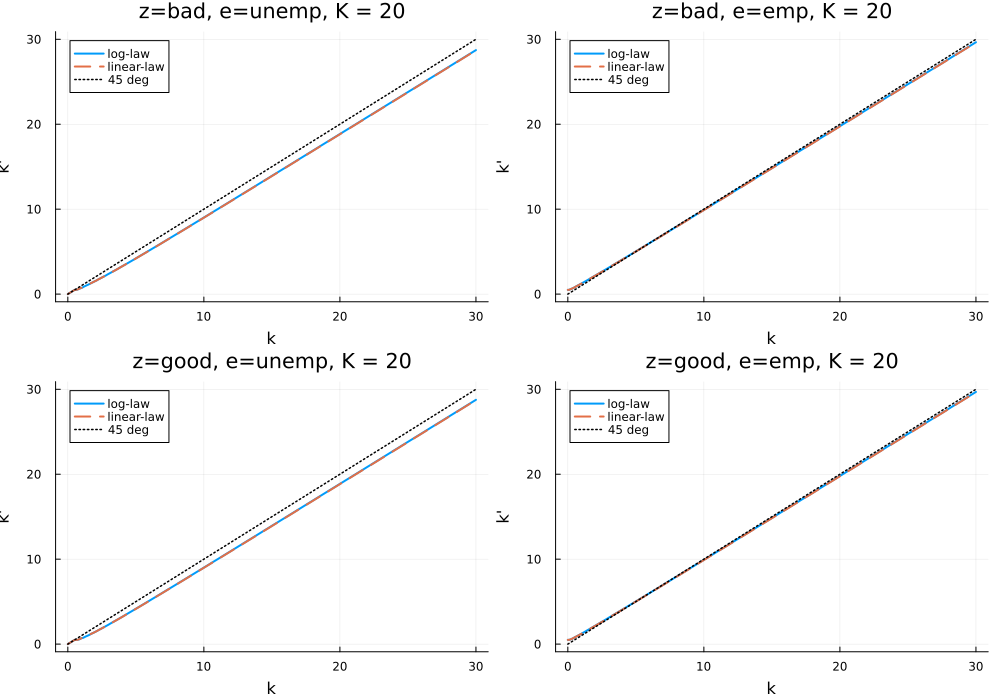

In [10]:
# Compare results of two perceived laws of motion:
#=
Log version: log K' = a_z + b_z log K
Estimated parameters:
bad state : a = 0.0874, b = 0.9634, R^2 = 0.999792
good state: a = 0.0913, b = 0.9639, R^2 = 0.999899

Linear version: K' = a_z + b_z K
Estimated parameters:
bad state : a = 0.4280, b = 0.9606, R^2 = 0.999793
good state: a = 0.4312, b = 0.9657, R^2 = 0.999899
=#

include(raw"C:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\PhD_first_year\ECON8107\KS1998\src\KSFunctions.jl")
using .KSFunctions
using Serialization, Printf, Statistics, Plots

const KSParams = KSFunctions.KSParams


# =========================================================
# 0) Load saved results
# =========================================================
log_path = raw"C:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\PhD_first_year\ECON8107\KS1998\notebooks\ks_log_result.jls"
lin_path = raw"C:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\PhD_first_year\ECON8107\KS1998\notebooks\ks_linear_result.jls"

log_bundle = deserialize(log_path)
lin_bundle = deserialize(lin_path)

log_res = log_bundle["res"]
lin_res = lin_bundle["res"]

log_par = log_bundle["par"]
lin_par = lin_bundle["par"]

log_coeff = log_bundle["coeff_star"]
lin_coeff = lin_bundle["coeff_star"]

log_kgrid = log_bundle["kgrid"]
lin_kgrid = lin_bundle["kgrid"]

log_Kgrid = log_bundle["Kgrid"]
lin_Kgrid = lin_bundle["Kgrid"]

log_pol = log_bundle["pol_star"]
lin_pol = lin_bundle["pol_star"]

log_K_series = log_bundle["K_series_final"]
lin_K_series = lin_bundle["K_series_final"]

log_z_path = log_bundle["z_path_final"]
lin_z_path = lin_bundle["z_path_final"]

# =========================================================
# 1) Compare solved results
# =========================================================
println("===================================================")
println("Comparison of solved perceived laws of motion")
println("===================================================")

println("\n[Log-law notebook]")
println("law_type = ", log_bundle["law_type"])
println("coeff = ")
display(log_coeff)
println("R2 by state = ", log_res.r2)

println("\n[Linear-law notebook]")
println("law_type = ", lin_bundle["law_type"])
println("coeff = ")
display(lin_coeff)
println("R2 by state = ", lin_res.r2)

println("\nSummary table")
@printf("%-12s | %-12s | %-12s | %-12s | %-12s\n", "Law", "a_bad", "b_bad", "a_good", "b_good")
@printf("%-12s | %-12.6f | %-12.6f | %-12.6f | %-12.6f\n",
        "log", log_coeff[1,1], log_coeff[1,2], log_coeff[2,1], log_coeff[2,2])
@printf("%-12s | %-12.6f | %-12.6f | %-12.6f | %-12.6f\n",
        "linear", lin_coeff[1,1], lin_coeff[1,2], lin_coeff[2,1], lin_coeff[2,2])

@printf("\n%-12s | %-12s | %-12s\n", "Law", "R2_bad", "R2_good")
@printf("%-12s | %-12.6f | %-12.6f\n", "log", log_res.r2[1], log_res.r2[2])
@printf("%-12s | %-12.6f | %-12.6f\n", "linear", lin_res.r2[1], lin_res.r2[2])


# =========================================================
# 2) Compare implied law of motion curves
# =========================================================
K_range = collect(range(1.0, 30.0, length = 300))

Kprime_log_bad = exp.(log_coeff[1,1] .+ log_coeff[1,2] .* log.(K_range))
Kprime_log_good = exp.(log_coeff[2,1] .+ log_coeff[2,2] .* log.(K_range))

Kprime_lin_bad = lin_coeff[1,1] .+ lin_coeff[1,2] .* K_range
Kprime_lin_good = lin_coeff[2,1] .+ lin_coeff[2,2] .* K_range

pLaw = plot(K_range, Kprime_log_bad, lw=2, label="Log law: bad state",
            xlabel="K", ylabel="K'", title="Perceived Law of Motion Comparison")
plot!(pLaw, K_range, Kprime_log_good, lw=2, label="Log law: good state")
plot!(pLaw, K_range, Kprime_lin_bad, lw=2, ls=:dash, label="Linear law: bad state")
plot!(pLaw, K_range, Kprime_lin_good, lw=2, ls=:dash, label="Linear law: good state")
display(pLaw)

# =========================================================
# 3) Compare simulated aggregate K_t paths
# =========================================================
println("\n===================================================")
println("Comparison of simulated aggregate capital paths")
println("===================================================")

@printf("%-12s | %-12s | %-12s | %-12s | %-12s\n", "Law", "mean(K)", "std(K)", "min(K)", "max(K)")
@printf("%-12s | %-12.6f | %-12.6f | %-12.6f | %-12.6f\n",
        "log", mean(log_K_series), std(log_K_series), minimum(log_K_series), maximum(log_K_series))
@printf("%-12s | %-12.6f | %-12.6f | %-12.6f | %-12.6f\n",
        "linear", mean(lin_K_series), std(lin_K_series), minimum(lin_K_series), maximum(lin_K_series))

Tplot = min(2000, min(length(log_K_series), length(lin_K_series)))
tt = 1:Tplot

pK = plot(tt, log_K_series[tt], lw=2, label="log-law",
          xlabel="t", ylabel="K_t", title="Aggregate Capital Path Comparison")
plot!(pK, tt, lin_K_series[tt], lw=2, ls=:dash, label="linear-law")
display(pK)

# =========================================================
# 4) Compare policy functions at K = 20
# =========================================================
function nearest_index_local(grid::Vector{Float64}, x::Float64)
    j = searchsortedfirst(grid, x)
    if j <= 1
        return 1
    elseif j > length(grid)
        return length(grid)
    else
        return abs(grid[j] - x) < abs(grid[j - 1] - x) ? j : j - 1
    end
end

K_fixed = 20.0
iK_log = nearest_index_local(log_Kgrid, K_fixed)
iK_lin = nearest_index_local(lin_Kgrid, K_fixed)

state_titles = Dict(
    (1,1) => "z=bad, e=unemp",
    (1,2) => "z=bad, e=emp",
    (2,1) => "z=good, e=unemp",
    (2,2) => "z=good, e=emp"
)

pPol = plot(layout=(2,2), size=(1000,700), legend=:topleft)

panel = 1
for iz in 1:2
    for ie in 1:2
        kp_log = vec(log_pol[:, iK_log, ie, iz])
        kp_lin = vec(lin_pol[:, iK_lin, ie, iz])

        plot!(pPol[panel], log_kgrid, kp_log, lw=2, label="log-law")
        plot!(pPol[panel], lin_kgrid, kp_lin, lw=2, ls=:dash, label="linear-law")
        plot!(pPol[panel], log_kgrid, log_kgrid, lw=1.5, ls=:dot, color=:black, label="45 deg")

        xlabel!(pPol[panel], "k")
        ylabel!(pPol[panel], "k'")
        title!(pPol[panel], "$(state_titles[(iz,ie)]), K = 20")
        panel += 1
    end
end

display(pPol)


From the figures above, we can see that although log law of motion and linear law of motion have difference in (K,K') space, however, it's not a big difference. 

Moreover, because the simulated path of $K_t$ is walking around 10, and in that region, the log function and linear function are quite close to each other. This leads to similar HH problems, thus similar policy functions and similar dynamics of $K_t$, which in turn leads to similar paths of $K_t$, policy function, and the Den Haan diagnostic.

We can also check this from the perspective of the derivatives of the law of motion.

We already have:
$$
K' = A(K,z)+B(K,z)K.
$$

We can approximate the derivative as:
$$
\frac{dK'}{dK} \approx B(K,z) + K \frac{\partial B(K,z)}{\partial K} + \frac{\partial A(K,z)}{\partial K} \approx C(K,z)
$$

In the simulation path of $K_t$, we can say that $K_t$ is relatively stablev around a certain value $\bar K$, thus we can approximate:
$$
C(K,z) \approx C(\bar K,z) = D(z).
$$

Therefore, the linear law of motion might be a good approximation to the true law of motion. Log law of motion is also a good approximation to the true law of motion due to the similar reason as above.


# Check the path of second moments of the distribution of assets

Previously, we have checked the path of the first moment of the distribution of assets, $K_t$. $K_t$ is relatively stable, which makes the log function and linear function close to each other, thus leading to similar results for the two perceived laws of motion.

But we know that $A(K,z)$ and $B(K,z)$ doesn't only depend on the first moment of the distribution of assets $K$, it depends on the whole distribution of assets $\phi$, which means:
$$
K' = A(\phi,z)+B(\phi,z)K.
$$

Thus, i want to check whether the approximation of $A(\phi,z) \approx A(K,z)$ and $B(\phi,z) \approx B(K,z)$ is reasonable.

## Check the path of second moments of the distribution of assets

Let $Var(K)$ denote the second moment of the distribution of assets, we can assume a more accurate form of the aggregate law of motion as
$$
K' = A(K,Var(K),z)+B(K,Var(K),z)K.
$$

I wanna check whether the second moments of the distribution of assets is also stable, so we can ignore the dependence of $A$ and $B$ on $Var(K)$, thus leading to similar results for the two perceived laws of motion.

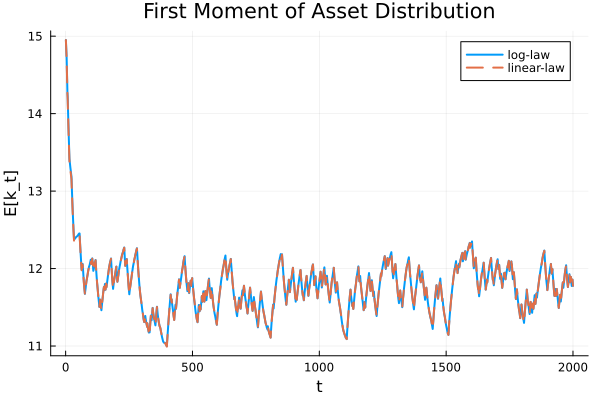

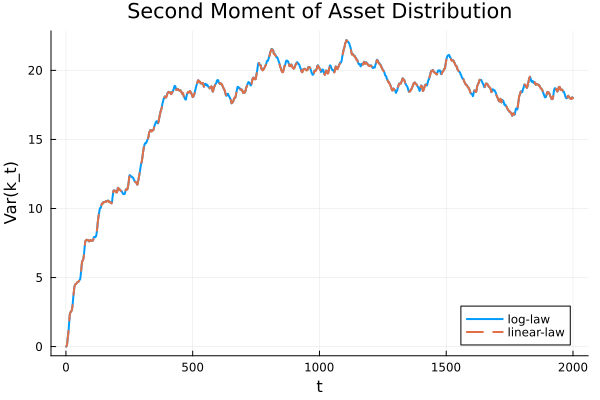


Comparison of first and second moments of asset distribution
Mean asset path diff (sup)     = 3.354515e-02
Variance path diff (sup)       = 5.402087e-02


In [11]:
# =========================================================
# 8) Simulate first and second moments of the asset distribution
#    using the already-solved policies (no re-solving)
# =========================================================

using Random

function generate_common_shocks_local(par; seed = 1234)
    rng = MersenneTwister(seed)
    T, N = par.T_sim, par.N_agents

    return (
        z_draws = rand(rng, T),
        emp_draws = rand(rng, T, N),
        k_draws = rand(rng, T, N),
        init_emp_draws = rand(rng, N)
    )
end

@inline state_index_local(ie::Int, iz::Int) = (iz - 1) * 2 + ie

function p_emp_next_local(par, ie::Int, iz::Int, izp::Int)
    cur_state = state_index_local(ie, iz)
    pz = par.Pz[iz, izp]

    if pz <= 1.0e-12
        return ie == 2 ? 1.0 : 0.0
    end

    emp_state = state_index_local(2, izp)
    p_emp = par.Pze[cur_state, emp_state] / pz
    return clamp(p_emp, 0.0, 1.0)
end

function simulate_asset_moments_local(par, kgrid, Kgrid, pol, shocks)
    T, N = par.T_sim, par.N_agents

    # start from middle asset grid point
    k_idx = fill(cld(length(kgrid), 2), N)
    e_state = [shocks.init_emp_draws[i] < (1.0 - par.u_rate[2]) ? 2 : 1 for i in 1:N]

    z_path = ones(Int, T + 1)
    z_path[1] = 2

    K_mean = zeros(T + 1)
    K_second = zeros(T + 1)
    K_var = zeros(T + 1)

    k_vals = kgrid[k_idx]
    K_mean[1] = mean(k_vals)
    K_second[1] = mean(k_vals .^ 2)
    K_var[1] = K_second[1] - K_mean[1]^2

    for t in 1:T
        iz = z_path[t]
        Kt = mean(kgrid[k_idx])

        K_mean[t] = mean(kgrid[k_idx])
        K_second[t] = mean((kgrid[k_idx]) .^ 2)
        K_var[t] = K_second[t] - K_mean[t]^2

        iKlo, iKhi, wK = KSFunctions.linear_interp_weights(Kgrid, Kt)

        izp = shocks.z_draws[t] <= par.Pz[iz, 1] ? 1 : 2
        z_path[t + 1] = izp

        k_next_idx = similar(k_idx)
        e_next_state = similar(e_state)

        for i in 1:N
            ie = e_state[i]
            ik = k_idx[i]

            kp_lo = pol[ik, iKlo, ie, iz]
            kp_hi = pol[ik, iKhi, ie, iz]
            kp_star = (1.0 - wK) * kp_lo + wK * kp_hi

            ik_lo, ik_hi, wk = KSFunctions.linear_interp_weights(kgrid, kp_star)
            k_next_idx[i] = shocks.k_draws[t, i] < wk ? ik_hi : ik_lo

            p_emp = p_emp_next_local(par, ie, iz, izp)
            e_next_state[i] = shocks.emp_draws[t, i] < p_emp ? 2 : 1
        end

        k_idx = k_next_idx
        e_state = e_next_state

        k_vals = kgrid[k_idx]
        K_mean[t + 1] = mean(k_vals)
        K_second[t + 1] = mean(k_vals .^ 2)
        K_var[t + 1] = K_second[t + 1] - K_mean[t + 1]^2
    end

    return (; z_path, K_mean, K_second, K_var)
end

common_shocks = generate_common_shocks_local(par; seed = 1234)

mom_log = simulate_asset_moments_local(par, log_kgrid, log_Kgrid, log_pol, common_shocks)
mom_lin = simulate_asset_moments_local(par, lin_kgrid, lin_Kgrid, lin_pol, common_shocks)

println("\n===================================================")
println("Comparison of first and second moments of asset distribution")
println("===================================================")

@printf("Mean asset path diff (sup)     = %.6e\n", maximum(abs.(mom_log.K_mean .- mom_lin.K_mean)))
@printf("Variance path diff (sup)       = %.6e\n", maximum(abs.(mom_log.K_var .- mom_lin.K_var)))

Tplot_mom = min(2000, min(length(mom_log.K_mean), length(mom_lin.K_mean)))
tt = 1:Tplot_mom

pMean = plot(tt, mom_log.K_mean[tt], lw=2, label="log-law",
    xlabel="t", ylabel="E[k_t]", title="First Moment of Asset Distribution")
plot!(pMean, tt, mom_lin.K_mean[tt], lw=2, ls=:dash, label="linear-law")


pVar = plot(tt, mom_log.K_var[tt], lw=2, label="log-law",
    xlabel="t", ylabel="Var(k_t)", title="Second Moment of Asset Distribution")
plot!(pVar, tt, mom_lin.K_var[tt], lw=2, ls=:dash, label="linear-law")

display(pMean)
display(pVar)


Second moments of the distribution of assets stablized after around 500 periods, and the difference between the two cases is also very small. 

In our training process (Estimate parameters in law of motion), we exclude the first 1000 periods, thus we can say that the second moments of the distribution of assets are also stable in our estimation sample.

Thus, we may be able to ignore the dependence of $A$ and $B$ on $Var(K)$ and $K$, which leads to:
$$
A(K,Var(K),z) \approx A(\bar K,\overline{Var(K)},z) = D(z),
\qquad
B(K,Var(K),z) \approx B(\bar K,\overline{Var(K)},z) = E(z).
$$

This further confirms that the two perceived laws of motion are good approximations to the true law of motion in this case.